# Feeding Chart Visualization and Interpolation
In the last exercise, you learned how to use pandas for querying the feeding table to answer specific diet-related questions. In the following, you will learn how to use `matplotlib` to visualize the table's data because one of the main jobs of a data scientist or data analyst is to present data appropriately. Moreover, visualizing data helps to understand it better. The second part is about Linear Regression using `NumPy` and `sklearn`. Finally, the result of this exercise is a tool that allows querying the feeding chart table using Linear Regression.

![linear-regression-example](img/univariate-polynom.png)

In [1]:
import pandas as pd

df = pd.read_csv('plan_pandas.csv').set_index('weight')

# 1. Basic Feeding Chart Visualization
In the following, please visualize the feeding chart with a line plot for each weight in different colors using the Axes' `plot()` method. For that purpose, please use the explicit `pyplot` interface and create a figure and axes manually.

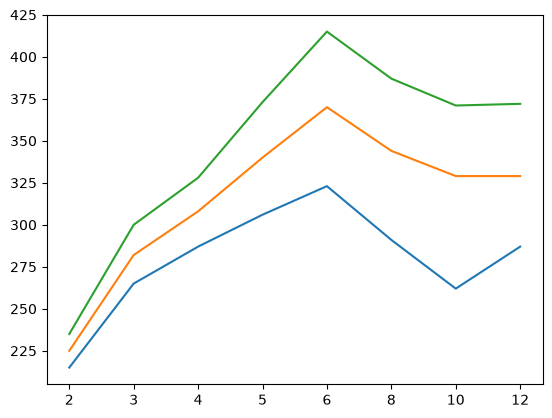

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()

for weight in df.index:
    ax.plot(df.columns, df.loc[weight])

plt.show()


Please have a look at the values on the ordinate. Are they appropriately distributed? Please study the type of the `DataFrame` columns and ensure that they are interpreted as integers. Recreate the diagram and discuss the results.

**Antwort:** Nein. Die Monatsangaben (2, 3, 4, 5, ..., 12) liegen nicht gleichmäßig auseinander: Zwischen den ersten Werten liegt jeweils ein Monat, zwischen den letzten Werten (6, 8, 10, 12) aber zwei Monate. `pd.read_csv` liest die Spaltennamen jedoch als Text (`str`) ein. Matplotlib interpretiert Text-Werte auf der Abszisse als *kategoriale* Daten und zeichnet sie deshalb in gleichmäßigem Abstand - der oben erzeugte Plot verzerrt also den tatsächlichen zeitlichen Verlauf. Wandelt man die Spalten stattdessen in `int` um, behandelt matplotlib die x-Achse als echte numerische Achse, und der größere Abstand zwischen den späteren Messpunkten wird sichtbar.

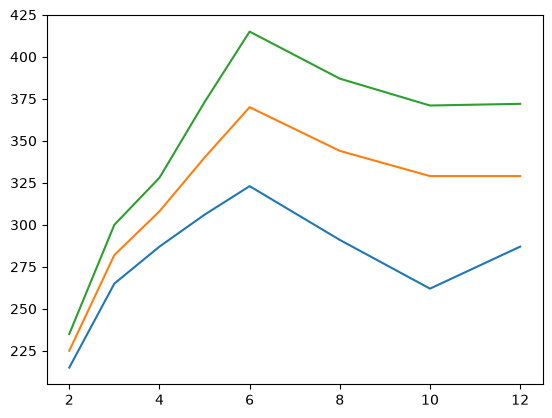

In [3]:
df.columns = df.columns.astype(int)

fig, ax = plt.subplots()

for weight in df.index:
    ax.plot(df.columns, df.loc[weight])

plt.show()


  # 2. Custom Line Styles
  Choosing different colors is sometimes not enough. For example, imagine you found an interesting paper and want to print it in black and white to add some hand-made notes. What happens with the lines? It could be hard to differentiate them. One way to overcome this is to use different *styles*. 
  
  Please extend the plot and visualize every target weight line plot with varying styles of line. 

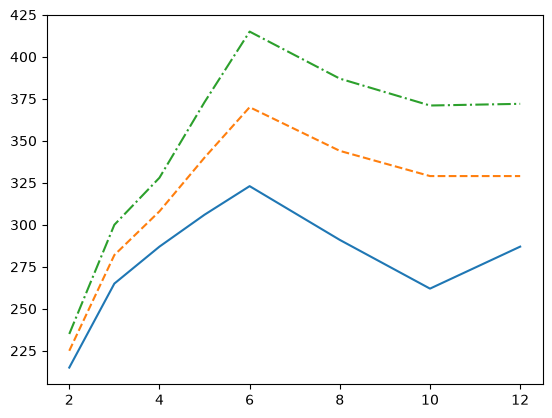

In [4]:
linestyles = ["-", "--", "-."]

fig, ax = plt.subplots()

for weight, linestyle in zip(df.index, linestyles):
    ax.plot(df.columns, df.loc[weight], linestyle=linestyle)

plt.show()


# 3. Paper-ready Figures
Now consider adding this plot to your thesis or an academic paper. Looking at the diagram, is it clear what data is used for generating it and what we *actually* see? As an academic, you want to be as transparent as possible so that other researchers can follow your ideas, statements, and conclusions you draw. Thus, your diagrams should contain all _relevant_ information that helps others understand it.

1. Add labels to the ordinate and abscissa so that readers know what attributes are shown.
2. Add a legend to the figure to depict the relationship between target weight and line plot. Adding a legend title is also a good choice ;)
3. In some cases, the legend might overlap with the diagram content. Thus, update the legend and put it above the figure. 

    1. Adapt the `ncol` parameter to align the entries horizontally. 
    2. Position the legend using the  `bbox_to_anchor` and `loc` parameters.

4. By default, matplotlib uses a figure size of $6.4 \times 4.8$ inches. Please change the figure size to $4 \times 2$ inches. For that purpose, study the `plt.subplots()` method.

5. In the academic domain, $\LaTeX$ is typically used to generate high-quality text documents. However, figures generated with `matplotlib` use other fonts by default. Please study the matplotlib documentation and enable text rendering with $\LaTeX$. 
    
    * On Ubuntu or other distros, you typically have to install the `type1cm` package. On Ubuntu, it is part of the `texlive-latex-extra` package.
    * Hint: The `plt.rcParams` contains the matplotlib configuration. You can update nearly every visual feature, such as font size, font family, default color palette, etc. To ensure the same style for different figures across multiple notebooks, you can create a new `setup()` function that initializes the matplotlib configuration to your needs.


**Hinweis:** `text.usetex` wird nur aktiviert, wenn auf dem System tatsächlich eine LaTeX-Installation (`latex`, `texlive-latex-extra`) gefunden wird. Auf einer Maschine mit installiertem LaTeX rendert matplotlib damit sämtlichen Text (Achsenbeschriftungen, Titel, Legende) über eine echte $\LaTeX$-Engine.

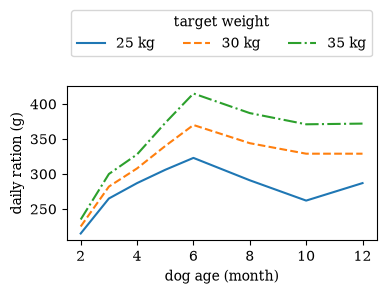

In [5]:
import shutil


def setup():
    """Configure matplotlib once so all figures in this notebook share the same style."""
    plt.rcParams["font.family"] = "serif"
    if shutil.which("latex"):
        plt.rcParams["text.usetex"] = True


setup()

fig, ax = plt.subplots(figsize=(4, 2))

for weight, linestyle in zip(df.index, linestyles):
    ax.plot(df.columns, df.loc[weight], linestyle=linestyle, label=f"{weight} kg")

ax.set_xlabel("dog age (month)")
ax.set_ylabel("daily ration (g)")
ax.legend(title="target weight", loc="lower center", bbox_to_anchor=(0.5, 1.15), ncol=len(df.index))

plt.show()


# 4. Transparent Data Representation

Let's take a second look at the diagrams - is it apparent what information is used to generate the lines? Is it possible to make it even more precise? Please highlight the data from the table with an explicit call of the `scatter()`. Ensure that the color of the points and the lines match.

The legend now might contain duplicate information. For each target weight, you have two entries: one for the lines and one for the point highlights. We want to drop the legend's point highlight entries and keep the line entries. Study the return value of the Axes' `plot()` method and the parameters of the `legend()` method. How can you explicitly set the entries of the legend and the labels? If not already done, use a `for` loop in combination with `zip()` to plot every line-style combination. 

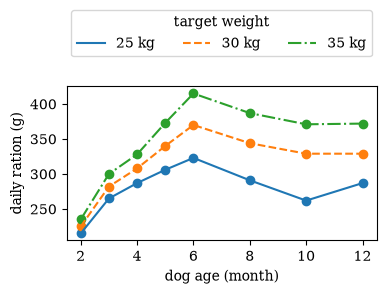

In [6]:
fig, ax = plt.subplots(figsize=(4, 2))

lines = []
for weight, linestyle in zip(df.index, linestyles):
    line, = ax.plot(df.columns, df.loc[weight], linestyle=linestyle, label=f"{weight} kg")
    ax.scatter(df.columns, df.loc[weight], color=line.get_color())
    lines.append(line)

ax.set_xlabel("dog age (month)")
ax.set_ylabel("daily ration (g)")
ax.legend(handles=lines, title="target weight", loc="lower center", bbox_to_anchor=(0.5, 1.15), ncol=len(df.index))

plt.show()


# 5. Consistent Data Representation

Up until now, we have visualized the charts using lines. But, do those lines really represent the feeding chart table? Consider the plotting task as a regression problem: what assumption do we make if we visualize the chart in that way?

**Antwort:** Verbindet man zwei benachbarte Messpunkte mit einer Geraden, unterstellt man implizit, dass sich die Tagesration *linear* zwischen zwei gemessenen Monaten ändert. Tatsächlich wird die Ration aber nur zu bestimmten Zeitpunkten neu festgelegt und bleibt bis zur nächsten Angabe konstant - die Daten stellen also eher eine Treppenfunktion (`step`) als eine stückweise lineare Funktion dar.

Let's assume that the daily ration should not change between the specified months. To properly depict this relation, we need to fix the diagram. 

1. Please extend the previous figure with a second Axes (see `plt.subplots()`) and visualize the following diagram in that new Axes. Again, please study the return values' types.
2. Use the step function for visualization and assume that the given daily ration in the table is valid until the next specified ration.
3. The legend's position at the top is not the best solution in this particular case. Please switch back to a column format and align the legend so that its top left corner is right of the second axes' top right corner. As before, have a look at the `bbox_to_anchor` and `loc` parameters.
4. Increase the figure size so that the axes have more space horizontally.
5. Both axes share the same ordinate and abscissa. Please add labels where appropriate. Study the `sharex` and `sharey` parameter of `plt.subplots()` and update your figure.
5. Export the figure to a `.png` and `.pdf` file and ensure that the background is transparent.

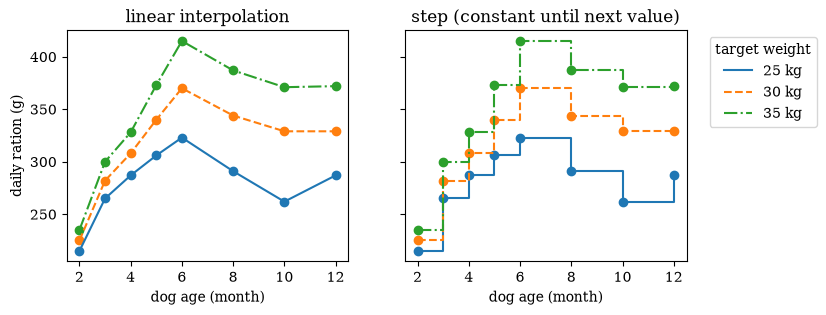

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3), sharex=True, sharey=True)

lines = []
for weight, linestyle in zip(df.index, linestyles):
    line, = ax1.plot(df.columns, df.loc[weight], linestyle=linestyle, label=f"{weight} kg")
    ax1.scatter(df.columns, df.loc[weight], color=line.get_color())
    lines.append(line)

    ax2.step(df.columns, df.loc[weight], where="post", linestyle=linestyle, color=line.get_color())
    ax2.scatter(df.columns, df.loc[weight], color=line.get_color())

ax1.set_title("linear interpolation")
ax2.set_title("step (constant until next value)")
ax1.set_xlabel("dog age (month)")
ax2.set_xlabel("dog age (month)")
ax1.set_ylabel("daily ration (g)")

fig.legend(handles=lines, title="target weight", loc="upper left", bbox_to_anchor=(0.92, 0.88))

fig.savefig("feeding_plan.png", transparent=True)
fig.savefig("feeding_plan.pdf", transparent=True)

plt.show()


# 6. Daily Ration Interpolation using Univariate Regression with Lines
Alright, we now have a good understanding of the data at hand. So, let's consider the following use case: one of your friends has a puppy and thinks the feeding chart information is insufficient. In particular, your friend wants to adapt the feeding ration daily to have a smoother change in the ration size. The friend knows that you do something with data; and thus asks you if you could develop a tool that allows your friend to ask for the feeding ration for a particular or multiple days, e.g., the upcoming week.

Of course, we want to help that friend. So, let's develop a python program that takes the feeding chart, provides a command line interface for user inputs, and prints the daily feeding ration for the queried day. Since the table does not contain the ration size on a daily basis, we need to estimate those values w.r.t the provided data. That is, we have to *interpolate* the missing values.

We will first focus on the data interpolation part since we need to find out how to approximate the data with a function appropriately. We start will the hypotheses space of straight lines. Please perform a univariate linear regression for the target weight of $25$ kg.

1. Select the feeding plan for the target weight of $25$ kg.
2. Create the data matrix based on the previous feeding plan by adding a row with only ones ( see `np.vstack()`). 
3. Use the `np.linalg.lstsq` method to estimate the weights of the best-fit hypothesis using the least-squares method. The weights are the first return value. Why do you need to add a row with ones in the previous step?

4. Visualize the line by predicting the values within the original data domain using `np.linspace`. Then, plot the hypothesis together with the step representation of the original data (ground truth). Analyze the results. Is a straight line a good choice of hypotheses space? How can you quantify the deviation of the hypothesis from the ground truth? For that purpose, please study the coefficient of determination $R^2$ and calculate it given the ground truth data and the hypothesis' predictions. Note that, if $\mathbf{y}$ is the ground truth value, $\hat{\mathbf{y}}$ the predicted value and $\bar{\mathbf{y}}$ the mean of $\mathbf{y}$, $R^2$ is defined as 

$$
R^2 = 1 - \frac{\sum\bigl(\mathbf{y} - \hat{\mathbf{y}}\bigr)^2}{\sum\bigl(\mathbf{y} - \bar{\mathbf{y}}\bigr)^2}
$$
5. We now want to perform the regression of multiple straight lines for all target weights using `np.linalg.lstsq()`. What is required to perform the regression for all three target weights at once? If you have estimated the weights, how can you predict the values using only a single matrix multiplication? For proper visualization, we will plot the ground truth information with the fitted line in three different Axes next to each other. Please prepare the figure to match the following result. 

![Multi Axes Figure](img/univariate.png)

6. Discuss the results of all fitted lines. How do the estimated hypotheses relate or differ from each other? Is the hypotheses space of straight lines appropriate to approximate the data? 

In [8]:
import numpy as np

x = df.columns.to_numpy(dtype=float)
y = df.loc[25].to_numpy(dtype=float)

X = np.vstack([x, np.ones_like(x)])
w, *_ = np.linalg.lstsq(X.T, y, rcond=None)
print("weights (slope, intercept):", w)


weights (slope, intercept): [  3.01754386 260.64035088]


**Antwort:** Ohne die Zeile aus Einsen könnte das Modell nur Geraden durch den Ursprung ($y = w_1 x$) darstellen. Die zusätzliche Zeile aus Einsen entspricht dem konstanten Term $x^0 = 1$ und liefert damit den y-Achsenabschnitt $w_0$, sodass beliebige Geraden $y = w_1 x + w_0$ gefittet werden können.

R^2 = 0.104


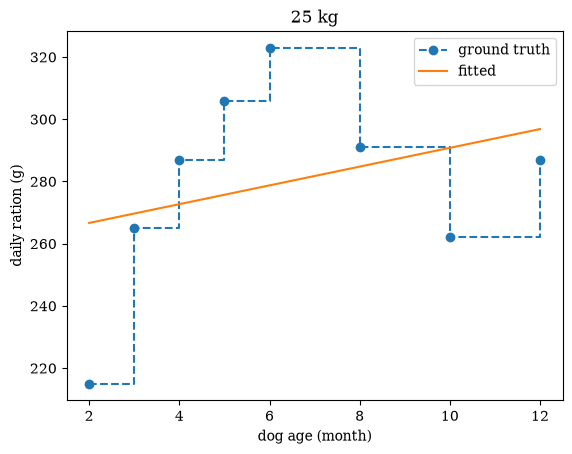

In [9]:
x_pred = np.linspace(x.min(), x.max(), 100)
X_pred = np.vstack([x_pred, np.ones_like(x_pred)])
y_pred = w @ X_pred

y_hat = w @ X
ss_res = np.sum((y - y_hat) ** 2)
ss_tot = np.sum((y - y.mean()) ** 2)
r2 = 1 - ss_res / ss_tot
print(f"R^2 = {r2:.3f}")

fig, ax = plt.subplots()
ax.step(x, y, where="post", marker="o", linestyle="--", label="ground truth")
ax.plot(x_pred, y_pred, label="fitted")
ax.set_xlabel("dog age (month)")
ax.set_ylabel("daily ration (g)")
ax.set_title("25 kg")
ax.legend()
plt.show()


**Antwort:** Die Gerade folgt dem allgemeinen (steigenden) Trend, kann aber den nicht-monotonen Verlauf der Daten (Anstieg bis Monat 6, dann wieder Abfall) nicht abbilden - eine Gerade ist ein zu einfacher Hypothesenraum. Das $R^2$ liegt deutlich unter $1$ und bestätigt, dass ein erheblicher Teil der Streuung nicht erklärt wird.

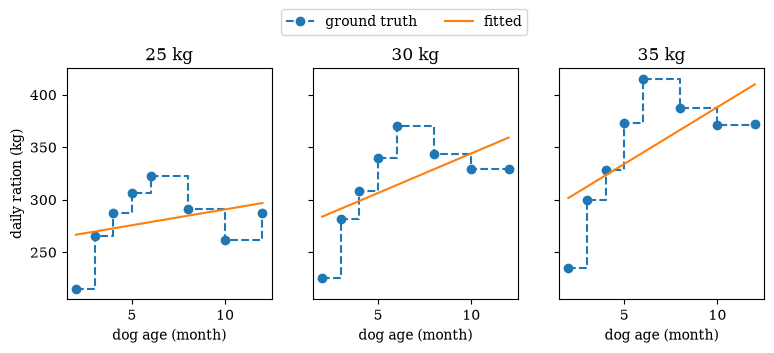

In [10]:
Y = df.to_numpy(dtype=float).T  # shape (N, 3), one column per target weight

W, *_ = np.linalg.lstsq(X.T, Y, rcond=None)  # shape (2, 3)
Y_pred = X_pred.T @ W  # shape (100, 3)

fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharex=True, sharey=True)

for ax, weight, y_pred_i in zip(axes, df.index, Y_pred.T):
    ax.step(df.columns, df.loc[weight], where="post", marker="o", linestyle="--", label="ground truth")
    ax.plot(x_pred, y_pred_i, label="fitted")
    ax.set_title(f"{weight} kg")
    ax.set_xlabel("dog age (month)")

axes[0].set_ylabel("daily ration (kg)")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.1), ncol=2)

plt.show()


**Antwort:** Für alle drei Zielgewichte hat `np.linalg.lstsq` dieselbe Datenmatrix `X` (die Monatsangaben sind für jede Kurve identisch) verwendet; nur die rechte Seite `Y` besteht jetzt aus drei Spalten statt einer. Da `lstsq` mehrere rechte Seiten gleichzeitig lösen kann, liefert ein einziger Aufruf für jede Spalte von `Y` einen eigenen Gewichtsvektor - zusammengefasst in der Matrix `W`. Die Vorhersage für alle drei Geraden lässt sich dadurch mit der einzigen Matrixmultiplikation `X_pred.T @ W` berechnen. Alle drei Geraden zeigen einen ähnlichen, monoton steigenden Trend mit vergleichbarer Steigung - sie unterscheiden sich im Wesentlichen im Achsenabschnitt (höheres Zielgewicht → höhere Tagesration). Der nicht-monotone Verlauf der echten Daten zeigt aber, dass eine Gerade für keines der drei Zielgewichte eine gute Wahl des Hypothesenraums ist.

# 6. Daily Ration Interpolation with Polynomials
The last figure of the previous section clearly depicts one fact: The daily ration increases until a certain dog age and decreases afterward. When does the puppy get the highest daily ratio? Due to this change in ration size, we will try out higher-degree polynomials instead of a straight line (first-order polynomial). As before, we can estimate the polynomial coefficients using `np.linalg.lstsq`. For that purpose, however, we have to adjust the data matrix.

Note that the data matrix $\mathbf{X} \in \mathrm{R}^{m+1, N}$ for a $m^{th}$ order polynomial has $N$ columns and $m+1$ rows because 

$$
\begin{aligned}
y(x) =& w_mx^m + w_{m-1}x^{m-1} + \dots w_0x^0 \\
\mathbf{y}_i = & \mathbf{w}\cdot \mathbf{x}_i \\
\mathbf{y}_i =& \begin{bmatrix}w_m \\ w_{m-1} \\ \dots \\ w_1\\ w_0 \end{bmatrix} \cdot \begin{bmatrix}x^m \\ x^{m-1} \\ \dots \\x^1 \\ x^0 = 1 \end{bmatrix} \\
\mathbf{y} =& \mathbf{w}^T \mathbf{X} \\
        =& \begin{bmatrix}w_m \\ w_{m-1} \\ \dots \\ w_0 \end{bmatrix}^T \begin{bmatrix}
            \mathbf{x}_1 & \mathbf{x}_2 & \dots & \mathbf{x}_N \\
        \end{bmatrix} \\
        =& \begin{bmatrix}w_m \\ w_{m-1} \\ \dots \\ w_1 \\ w_0 \end{bmatrix}^T \begin{bmatrix}
            x_{1}^m           & x_{2}^m             & \dots     & x_{N}^m \\ 
            x_{1}^{m-1}    & x_{2}^{m-1}      & \dots     & x_{N}^{m-1} \\
            \vdots      & \vdots        & \ddots    & \vdots \\
            x_{1}^{1}    & x_{2}^{1}      & \dots     & x_{N}^1 \\
            1           & 1             & \dots     & 1
        \end{bmatrix}
\end{aligned}
$$

if $y$ is a row vector. Hence, we have $m+1$ weights for a $m^{th}$ order polynomial. We solve the regression problem for a $3^{rd}$ order polynomial for the target weight of $25$ kg.

1. Create the data matrix using `np.repeat()` and `np.power()`. Do not use for loops! You can reshape a row vector to a column vector with `np.newaxis` (for further details, see lecture [arithmetric operations in NumPy](https://gitlab.gwdg.de/hsel/ss_2026/maschinelles_lernen_1/vorlesung/-/blob/4062b860d83004ac13a49b17e93ff250fd2d6f11/ml1-python-03-arithmetric-operations-in-numpy.pdf)). Furthermore, consider defining the polynomial degree with a variable.
2. Estimate the best-fit hypothesis' weights using `np.linalg.lstsq()`. What are the weights of the best-fit hypothesis?
3. Generate a new matrix for interpolation in the original data domain using `np.linspace`, `np.repeat()`, and `np.power()`. 
4. Interpolate the missing values using matrix multiplication (e.g., using $@$ sign)
5. Visualize the ground truth information with the fitted polynomial. Ensure that labels, titles, and the legend are adequately populated.
6. Again, extend your result and perform the linear regression for the three target weights at once. Create a figure with three Axes and show the ground truth data, best-fit line hypothesis and best-fit $3^{rd}$ order polynomial.
7. The library `sklearn` provides the class `LinearRegression` with the widely-used `fit()` and `predict()` interface. Feel free to duplicate the previous results and try out the `LinearRegression` class. The `score()` method also allows quantifying the prediction of the model w.r.t ground truth data using the coefficient of determination. Moreover, the `numpy.polyfit` function allows fitting polynomials of various orders and `numpy.polyval` can be employed for prediction.
8. Finally, try out different higher-order polynomials and analyze the results. What happens if you choose a hypothesis space of polynomials with a large degree? Choose an appropriate polynomial for each target weight and reason your decision.

In [11]:
degree = 3

exponents = np.arange(degree, -1, -1)[:, np.newaxis]  # shape (degree + 1, 1)
X_poly = np.power(np.repeat(x[np.newaxis, :], degree + 1, axis=0), exponents)

w_poly, *_ = np.linalg.lstsq(X_poly.T, y, rcond=None)
print("polynomial weights (highest degree first):", w_poly)


polynomial weights (highest degree first): [  0.73725608 -17.64257679 127.45074339  21.51325245]


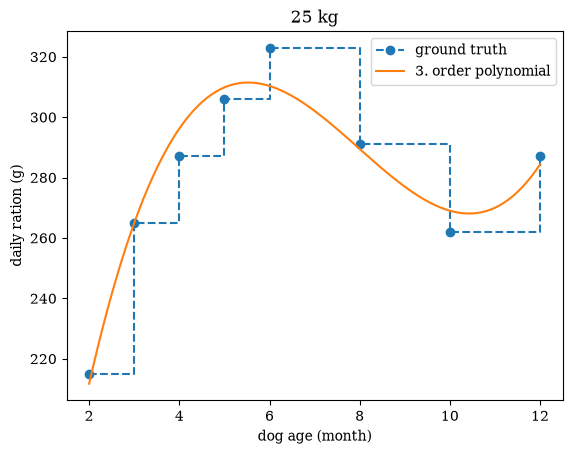

In [12]:
X_poly_pred = np.power(np.repeat(x_pred[np.newaxis, :], degree + 1, axis=0), exponents)
y_poly_pred = w_poly @ X_poly_pred

fig, ax = plt.subplots()
ax.step(x, y, where="post", marker="o", linestyle="--", label="ground truth")
ax.plot(x_pred, y_poly_pred, label=f"{degree}. order polynomial")
ax.set_xlabel("dog age (month)")
ax.set_ylabel("daily ration (g)")
ax.set_title("25 kg")
ax.legend()
plt.show()


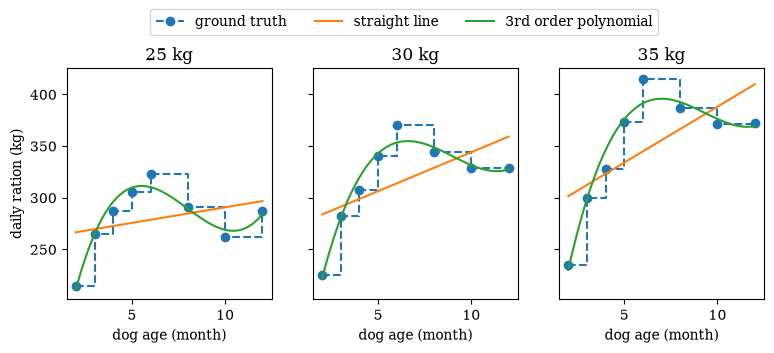

In [13]:
W_poly, *_ = np.linalg.lstsq(X_poly.T, Y, rcond=None)  # shape (degree + 1, 3)
Y_poly_pred = X_poly_pred.T @ W_poly  # shape (100, 3)

fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharex=True, sharey=True)

for ax, weight, y_pred_i, y_poly_pred_i in zip(axes, df.index, Y_pred.T, Y_poly_pred.T):
    ax.step(df.columns, df.loc[weight], where="post", marker="o", linestyle="--", label="ground truth")
    ax.plot(x_pred, y_pred_i, label="straight line")
    ax.plot(x_pred, y_poly_pred_i, label=f"{degree}rd order polynomial")
    ax.set_title(f"{weight} kg")
    ax.set_xlabel("dog age (month)")

axes[0].set_ylabel("daily ration (kg)")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.1), ncol=3)

plt.show()


In [14]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()
reg.fit(x.reshape(-1, 1), y)
print("sklearn weights (slope, intercept):", reg.coef_[0], reg.intercept_)
print("sklearn R^2:", reg.score(x.reshape(-1, 1), y))

coefficients_polyfit = np.polyfit(x, y, degree)
y_polyfit_pred = np.polyval(coefficients_polyfit, x_pred)
print("np.polyfit weights (highest degree first):", coefficients_polyfit)
print("max. |np.linalg.lstsq - np.polyfit| deviation:", np.max(np.abs(y_poly_pred - y_polyfit_pred)))


sklearn weights (slope, intercept): 3.0175438596491233 260.640350877193
sklearn R^2: 0.10358253270216489
np.polyfit weights (highest degree first): [  0.73725608 -17.64257679 127.45074339  21.51325245]
max. |np.linalg.lstsq - np.polyfit| deviation: 1.375610736431554e-11


**Antwort:** `LinearRegression.fit()` liefert (bis auf Rundungsfehler) dieselben Gewichte wie `np.linalg.lstsq` für die Gerade, und `np.polyfit` liefert dieselben Koeffizienten wie unsere manuell gebaute Datenmatrix für das Polynom - beide Wege lösen intern dasselbe Least-Squares-Problem. `LinearRegression.score()` gibt direkt das $R^2$ zurück und erspart die manuelle Berechnung.

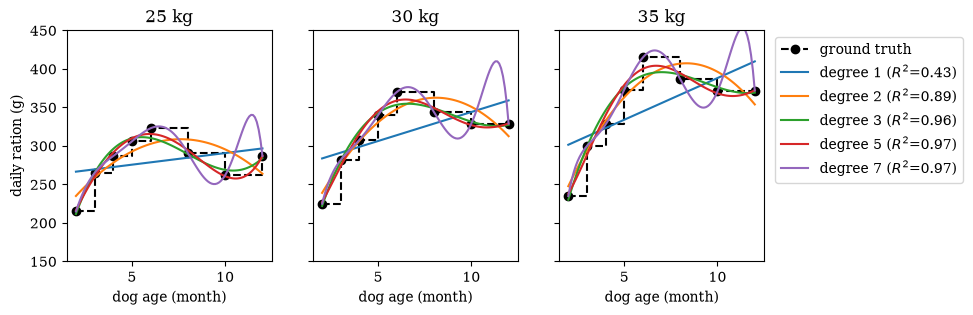

In [15]:
degrees = [1, 2, 3, 5, 7]

fig, axes = plt.subplots(1, 3, figsize=(9, 3), sharex=True, sharey=True)

for ax, weight in zip(axes, df.index):
    y_weight = df.loc[weight].to_numpy(dtype=float)
    ax.step(df.columns, y_weight, where="post", marker="o", linestyle="--", color="black", label="ground truth")

    for d in degrees:
        coefficients = np.polyfit(x, y_weight, d)
        y_d_pred = np.polyval(coefficients, x_pred)
        r2_d = LinearRegression().fit(
            np.vander(x, d + 1, increasing=False), y_weight
        ).score(np.vander(x, d + 1, increasing=False), y_weight)
        ax.plot(x_pred, y_d_pred, label=f"degree {d} ($R^2$={r2_d:.2f})")

    ax.set_title(f"{weight} kg")
    ax.set_xlabel("dog age (month)")
    ax.set_ylim(150, 450)

axes[0].set_ylabel("daily ration (g)")
axes[-1].legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))

plt.show()


**Antwort:** Mit steigendem Polynomgrad steigt das $R^2$ auf den Trainingsdaten monoton bis auf $1$: bei Grad $7$ besitzt die Datenmatrix genauso viele Spalten wie Messpunkte, sodass das Polynom exakt durch jeden einzelnen Messpunkt verläuft (reine Interpolation, *overfitting*). Zwischen und außerhalb der Messpunkte schwingt die Kurve dabei jedoch stark (Runge-Phänomen) und ist damit als Modell für die tatsächliche Fütterungsration unbrauchbar. Ein Polynom 3. Grades bildet den Anstieg und den anschließenden Abfall der Tagesration gut nach, bleibt zwischen den Messpunkten aber glatt und plausibel - für alle drei Zielgewichte ist Grad $3$ daher ein guter Kompromiss zwischen Anpassungsgüte und Modellkomplexität.

# 7. Wrapping up (optional)
Jupyter notebooks are great for rapid prototyping and explorative data analysis, as we did in this exercise. However, although we could spend ages digging into the data, let's not forget the friend and the actual reason for doing all this. So, let's take the quintessence of all the analysis so far and wrap it up into a real command-line program!

Your friend has the following use cases which you should use for designing the application using the [`fire`](https://github.com/google/python-fire) library.

1. Get the daily ration size by specifying the dog's age as single days with the argument `age`.

2. Get the daily ration size for the given age in days using the `age` flag and all $n$ following days with the `duration` flag.

3. Your friend is interested in having an overview of the overall plan. For that purpose, add an `export` flag that allows saving the feeding plan depicted as the best-fit hypothesis with user-specified day(s) highlighted appropriately. The `export` flag should allow specifying the target file name.

4. A well-designed command-line program provides information about all options and the program itself. Please describe the options for your friend to ensure that he/she can use that tool. A good starting point for an overview of the command-line tool is calling the program with `help`.

Die Umsetzung dieses Abschnitts befindet sich nicht in diesem Notebook, sondern im Kommandozeilen-Tool `main.py` im selben Verzeichnis (siehe `README.md` für Beispielaufrufe).